In [152]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [153]:
import pandas as pd

exp_data = catalog.load("experiment_data")
exp_data.head()

[06/10/26 14:50:18] INFO     Loading data from experiment_data (ExcelDataset)...               ]8;id=739113;file://c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=506706;file://c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

,id,T_melt,t_holdingpressure,Reskühlzeit_t_cooling,p_holdingpressure,V_injection,T_cooling,Zeit,Quality
0,1,210,0.1,2,200,6,30,12.18,0.0
1,2,210,0.1,2,200,12,30,11.11,0.0
2,3,210,0.1,2,200,20,30,10.71,0.0
3,4,210,0.1,2,350,6,30,12.30,0.0
4,5,210,0.1,2,350,12,30,11.27,0.0


In [154]:
exp_data.dtypes


id                         int64
T_melt                     int64
t_holdingpressure        float64
Reskühlzeit_t_cooling      int64
p_holdingpressure          int64
V_injection                int64
T_cooling                  int64
Zeit                     float64
Quality                  float64
dtype: object

In [155]:
exp_data.shape

(1120, 9)

In [156]:
partitioned_chart_data = catalog.load("chart_data")

                    INFO     Loading data from chart_data (PartitionedDataset)...              ]8;id=898042;file://c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=747533;file://c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

## Preprocessing

In [157]:
import re
from collections import defaultdict
from functools import reduce
from typing import Dict, Any, List

In [158]:
# Groups filenames using regex
def _group_partitions(partition_ids: List[str]) -> Dict[str, List[str]]:
    groups = defaultdict(list)
    pattern = re.compile(r"(.*_measurement_)\d+(_.*)")

    for p_id in partition_ids:
        match = pattern.match(p_id)
        if match:
            key = match.group(1) + match.group(2)
            groups[key].append(p_id)
    return groups


# Loads, cleans, and merges a single group of files
def _load_and_merge_group(partition_ids: List[str]) -> pd.DataFrame:
    df_list = []
    # Relative path ensures this works on ANY computer, not just yours!
    base_path = "data/01_raw/chart_data"

    for p_id in sorted(partition_ids):
        try:
            df = pd.read_csv(
                f"{base_path}/{p_id}.txt",
                sep=";",
                skiprows=11,
                encoding="utf-16",
                engine="python",
            )
            if df.empty:
                continue

            # Clean trailing columns and whitespaces
            df = df.iloc[:, :-1]
            df.columns = df.columns.str.strip()
            df_list.append(df)
        except Exception:
            continue

    if not df_list:
        return pd.DataFrame()

    # Outer merge all dataframes within this specific group
    return reduce(
        lambda left, right: pd.merge(left, right, on="time", how="outer"), df_list
    )


# The main orchestrator for processing chart_data
def preprocess_and_merge_charts(partitioned_input: Dict[str, Any]) -> pd.DataFrame:
    """Processes, cleans, outer-merges, and concatenates all chart data files."""

    # Step 1: Group the partitions
    groups = _group_partitions(list(partitioned_input.keys()))

    # Step 2: Merge data within each group
    merged_dfs = []
    for key, partition_ids in groups.items():
        df_merge = _load_and_merge_group(partition_ids)
        if not df_merge.empty:
            merged_dfs.append(df_merge)

    if not merged_dfs:
        return pd.DataFrame()

    # Step 3: Add incremental experiment IDs
    all_dfs = []
    for idx, df in enumerate(merged_dfs):
        cleaned_df = df[df["time"] != "-start data-"].dropna(subset=["time"])
        temp_df = cleaned_df.copy()
        temp_df["id"] = idx + 1
        all_dfs.append(temp_df)

    # Step 4: Combine, format types, and sort
    chart_data = pd.concat(all_dfs, ignore_index=True)
    chart_data = chart_data.apply(pd.to_numeric, errors="coerce")
    chart_data = chart_data.sort_values(by=["id", "time"]).reset_index(drop=True)

    return chart_data


# Get only relevant data with labels from experiment_data
def preprocess_experiment_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean the raw injection molding experiment data"""
    return df.dropna(subset=["Quality"])

In [159]:
exp_data = preprocess_experiment_data(exp_data)
exp_data.head()

,id,T_melt,t_holdingpressure,Reskühlzeit_t_cooling,p_holdingpressure,V_injection,T_cooling,Zeit,Quality
0,1,210,0.1,2,200,6,30,12.18,0.0
1,2,210,0.1,2,200,12,30,11.11,0.0
2,3,210,0.1,2,200,20,30,10.71,0.0
3,4,210,0.1,2,350,6,30,12.30,0.0
4,5,210,0.1,2,350,12,30,11.27,0.0


In [160]:
import os

# If you are inside the notebooks folder, hop out to the root project folder
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print(f"New Working Directory: {os.getcwd()}")

chart_data = preprocess_and_merge_charts(partitioned_chart_data)
chart_data.head()

New Working Directory: c:\Users\defaultuser100000\github_repos\digital_twin\digital-twin\digital-twin


,time,"Einspritzdruck, Ist","Schneckenvolumen, Ist","Auswerferweg, Ist","Einspritzstrom, Ist","Werkzeuggeschwindigkeit, Ist","Auswerfergeschwindigkeit, Ist","Werkzeugkraft, Ist","Werkzeugweg, Ist","Druckmesssystem 3, Ist","Temperaturmesssystem 5, Ist",id
0,0.00,-0.70,18.50,-0.02,0.00,-0.95,0.00,119.38,-0.02,0.0,31.1,1
1,0.05,22.98,18.34,-0.04,5.41,0.00,0.31,119.05,-0.02,0.0,31.2,1
2,0.10,25.27,18.04,-0.04,5.95,0.00,0.31,118.83,-0.02,0.0,31.1,1
3,0.15,26.96,17.75,-0.04,5.95,0.95,0.00,118.61,-0.02,0.0,31.1,1
4,0.20,38.99,17.45,-0.01,5.95,0.00,0.00,118.50,-0.02,0.0,31.1,1


In [264]:
chart_data = chart_data.drop(columns=['Auswerferweg, Ist', 'Werkzeuggeschwindigkeit, Ist', 'Auswerfergeschwindigkeit, Ist', 'Werkzeugweg, Ist'])

In [265]:
chart_data.columns


Index(['time', 'Einspritzdruck, Ist', 'Schneckenvolumen, Ist',
       'Einspritzstrom, Ist', 'Werkzeugkraft, Ist', 'Druckmesssystem 3, Ist',
       'Temperaturmesssystem 5, Ist', 'id'],
      dtype='object')

In [266]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

def plot_chart_data(chart_df: pd.DataFrame):

    # Initialize a new figure with specific dimensions
    plt.figure(figsize=(10,6))

    # Get a list of all column names except for "time" to identify the sensor parameters
    params = chart_df.columns.drop(["time", "id"])

    # scale data only for plot
    # scaler = MinMaxScaler()
    # scaled_chart_data = pd.DataFrame(scaler.fit_transform(chart_df[params]), columns=params)
    # scaled_chart_data['time'] = chart_df['time']
    # scaled_chart_data['id'] = chart_df['id']
    scaled_chart_data = chart_data

    # Iterate through the parameter list to plot each sensor's data
    for idx, param in enumerate(params):
        # Limit the plot to only the first 4 parameters to prevent visual clutter
        if idx == 5 or idx == 7:
            for id in range(33, 50):
                # Create a line plot for the current parameter against the time axis
                sns.lineplot(data=scaled_chart_data[scaled_chart_data['id'] == id], x='time', y=param, label=param)

    # # Set the descriptive title and axis labels for the chart
    # plt.title("Sensor Parameters")
    # plt.xlabel("time")
    # plt.ylabel("Param value")

    # # Place the legend in the bottom right corner to avoid overlapping with data lines
    # plt.legend(loc="lower right")

            # Render the final plot
            plt.show()

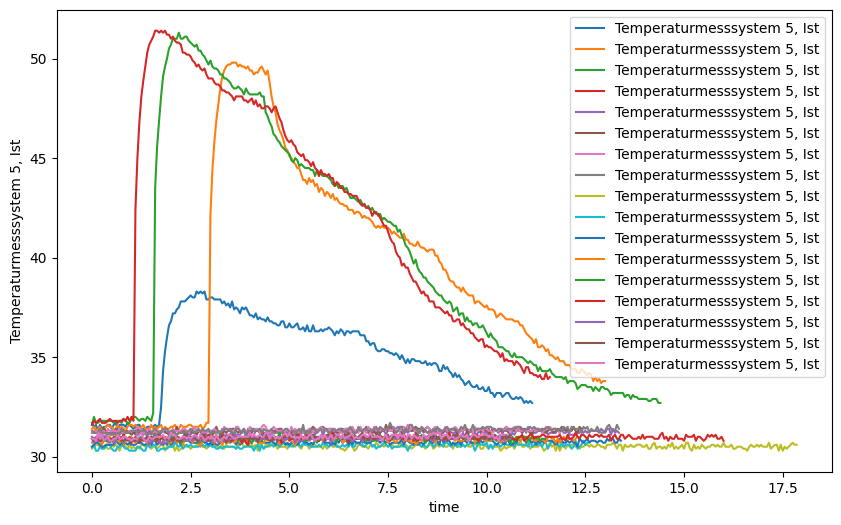

In [267]:
plot_chart_data(chart_data)

## Feature Engineering

In [268]:
from typing import Dict, Tuple
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split


def split_by_experiment_id(chart_df: pd.DataFrame, experiment_df: pd.DataFrame, parameters: Dict
                           ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Splits both time-series and label dataframes by stratified experiment IDs.

    This ensures that all time-steps for a given cycle ID stay together in
    either the train set or the test set, preventing leakage.

    Args:
        chart_df: Cleaned long-form time-series data.
        experiment_df: Input parameter and label dataset containing exactly one row per cycle ID.
        parameters: Pipeline parameter dictionary containing split settings.

    Returns:
        Tuple containing chart_train, chart_test, experiment_train, experiment_test
    """
    target_col = parameters["target_column"]  # e.g., "Quality"
    test_size = parameters["test_size"]
    random_state = parameters["random_state"]

    # Force the column to be an integer safely ---
    experiment_df[target_col] = experiment_df[target_col].astype("Int64")

    # 1. Stratify split the unique IDs using the label dataframe
    train_ids, test_ids = train_test_split(
        experiment_df["id"],
        test_size=test_size,
        random_state=random_state,
        stratify=experiment_df[target_col],
    )

    # 2. Slice the time-series chart data matching those IDs
    chart_train = chart_df[chart_df["id"].isin(train_ids)].reset_index(drop=True)
    chart_test = chart_df[chart_df["id"].isin(test_ids)].reset_index(drop=True)

    # 3. Slice the experiment label data matching those IDs
    experiment_train = experiment_df[experiment_df["id"].isin(train_ids)].reset_index(drop=True)
    experiment_test = experiment_df[experiment_df["id"].isin(test_ids)].reset_index(drop=True)

    return chart_train, chart_test, experiment_train, experiment_test


def _detect_cycle_phases(signal: pd.DataFrame, threshold_pct: float = 0.18) -> dict:
    """Internal helper to detect phase transition indices for a single cycle.

    Identifies transition frames based on initial gradient and sharpest drops.
    """
    # Filter for time > 0.4 to ignore initialization/pre-injection noise artifacts
    signal_to_use = signal["Einspritzstrom, Ist"][signal["time"] > 0.4]
    len_removed_signal = len(signal[signal["time"] <= 0.4])

    grad = np.gradient(signal_to_use)

    # --- Step A: Find injection phase end ---
    max_grad = np.max(np.abs(grad))
    significant_changes = np.where(np.abs(grad) > (max_grad * threshold_pct))[0]
    first_phase_end_idx = significant_changes[0] if len(significant_changes) > 0 else 0

    # --- Step B: Find holding and dosage drop peaks ---
    search_area = -grad[first_phase_end_idx:]
    peaks, props = find_peaks(search_area, height=0.03)
    peaks = peaks + first_phase_end_idx

    if len(peaks) < 2:
        return {}  # Graceful exit if the signal shape is unexpected

    strongest_indices = np.argsort(props["peak_heights"])[-2:]
    top_two_peaks = np.sort(peaks[strongest_indices])

    # --- Step C: Find decompression phase end ---
    last_phase_value = np.max(grad[int(top_two_peaks.max()) :])
    last_phase_index = np.where(np.isclose(grad, last_phase_value))[0]

    return {
        "yellow_injection": int(first_phase_end_idx) + len_removed_signal,
        "dark_blue_holding_pressure": int(top_two_peaks[0]) + len_removed_signal,
        "green_dosage": int(top_two_peaks[1]) + len_removed_signal - 1,
        "red_decompression": int(last_phase_index[0]) + len_removed_signal + 1,
    }


def transform_time_series_into_phases(df: pd.DataFrame) -> pd.DataFrame:
    """Orchestrates phase calculation and reshapes the dataframe for tsfresh.

    Iterates safely through available IDs, slices sensor variables into
    isolated horizontal blocks, and appends time tracking features.

    Args:
        df: Cleaned long-form time-series data containing columns 'id' and 'time'.

    Returns:
        full_joined_df: A phase-separated dataframe ready for tsfresh extraction.
    """
    unique_ids = df["id"].unique()
    all_dfs = []

    for cycle_id in unique_ids:
        # Filter dataframe for the current ID safely
        df_id = df[df["id"] == cycle_id].reset_index(drop=True)

        # Detect phase transitions for this specific ID
        phase_indices = _detect_cycle_phases(df_id, threshold_pct=0.18)
        if not phase_indices:
            continue

        # Extract timestamps for the phase boundaries
        t_inj = df_id.loc[phase_indices["yellow_injection"], "time"]
        t_hold = df_id.loc[phase_indices["dark_blue_holding_pressure"], "time"]
        t_dose = df_id.loc[phase_indices["green_dosage"], "time"]
        t_decomp = df_id.loc[phase_indices["red_decompression"], "time"]

        # Drop non-feature columns before adding suffixes
        features_only = df_id.drop(columns=["time", "id"], errors="ignore")

        # Slice features into distinct phase blocks based on time boundaries
        inj_df = features_only[df_id["time"] <= t_inj].add_suffix("_inj")
        hold_df = features_only[(df_id["time"] > t_inj) & (df_id["time"] <= t_hold)].add_suffix("_hold")
        dose_df = features_only[(df_id["time"] > t_hold) & (df_id["time"] <= t_dose)].add_suffix("_dosage")
        decomp_df = features_only[(df_id["time"] > t_dose) & (df_id["time"] <= t_decomp)].add_suffix("_decomp")

        # Horizontally merge phases. Missing rows in shorter phases auto-fill with NaN
        dfs_to_concat = [inj_df, hold_df, dose_df, decomp_df]
        joined_df = pd.concat([d.reset_index(drop=True) for d in dfs_to_concat], axis=1)

        # Append identification keys for tsfresh parsing
        joined_df["id"] = int(cycle_id)
        joined_df["time_stamp"] = joined_df.index + 1
        all_dfs.append(joined_df)

    if not all_dfs:
        return pd.DataFrame()

    full_joined_df = pd.concat(all_dfs, ignore_index=True)
    return full_joined_df

In [269]:
import math

def plot_phase_divisions(chart_df: pd.DataFrame):
    #cols = ['yellow_injection', 'dark_blue_holding_pressure', 'green_dosage', 'red_decompression']
    colors = ['gold', 'darkblue', 'green', 'red']

    # Calculate grid dimensions: 2 columns wide, rows as needed
    n_plots = chart_df['id'].nunique()
    n_cols = 2
    n_rows = math.ceil(n_plots / n_cols)

    # Create the figure and a flattened array of axes
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
    axes_flat = axes.flatten()

    for idx in range(0, n_plots):
        testing_signal = chart_df[['time', 'Einspritzstrom, Ist']][chart_df['id'] == idx+1].reset_index(drop=True)
        results = _detect_cycle_phases(testing_signal, 0.18) 

        ax = axes_flat[idx]
        try:
            # Plot onto the specific axis 'ax'
            sns.lineplot(data=testing_signal, x="time", y="Einspritzstrom, Ist", ax=ax)
            
            # Add vertical lines to the specific axis
            for x_val, color in zip(results, colors):
                ax.axvline(x=testing_signal.loc[results[x_val], 'time'], color=color, linestyle='--', alpha=0.6)
                
            ax.set_title(f"Analysis for id {idx+1}")
        except Exception as e:
            ax.set_title(f"Error at id {idx+1}")
        print(f"\n")
    
    # Hide any empty subplots if n_plots is not a multiple of 2
    for j in range(idx + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

In [270]:
plot_phase_divisions(chart_data)

In [271]:
# Parameters configuration file locally
parameters = {
    "target_column": "Quality",
    "test_size": 0.2,
    "random_state": 42
}

In [272]:
chart_train, chart_test, experiment_train, experiment_test = split_by_experiment_id(
    chart_df=chart_data, 
    experiment_df=exp_data, 
    parameters=parameters
)

# Verify the distributions
print("--- Splitting Complete ---")
print(f"Train data: {experiment_train['id'].nunique()} unique cycles")
print(f"Test data:  {experiment_test['id'].nunique()} unique cycles")
print(f"\nTrain Label Distribution:\n{experiment_train[parameters['target_column']].value_counts(normalize=True)}")

--- Splitting Complete ---
Train data: 124 unique cycles
Test data:  31 unique cycles

Train Label Distribution:
Quality
0    0.620968
1    0.379032
Name: proportion, dtype: Float64


In [273]:
chart_train

,time,"Einspritzdruck, Ist","Schneckenvolumen, Ist","Einspritzstrom, Ist","Werkzeugkraft, Ist","Druckmesssystem 3, Ist","Temperaturmesssystem 5, Ist",id
0,0.00,-0.70,18.50,0.00,119.38,0.00,31.1,1
1,0.05,22.98,18.34,5.41,119.05,0.00,31.2,1
2,0.10,25.27,18.04,5.95,118.83,0.00,31.1,1
3,0.15,26.96,17.75,5.95,118.61,0.00,31.1,1
4,0.20,38.99,17.45,5.95,118.50,0.00,31.1,1
...,...,...,...,...,...,...,...,...
33959,13.35,-1.29,18.50,0.00,0.00,-0.54,33.2,155
33960,13.40,-1.29,18.50,0.00,0.00,-0.54,32.9,155
33961,13.45,-1.39,18.50,0.00,0.00,-0.54,33.1,155
33962,13.50,-1.39,18.50,0.00,0.00,-0.54,33.1,155


In [274]:
chart_test

,time,"Einspritzdruck, Ist","Schneckenvolumen, Ist","Einspritzstrom, Ist","Werkzeugkraft, Ist","Druckmesssystem 3, Ist","Temperaturmesssystem 5, Ist",id
0,0.00,-0.50,18.50,0.0,119.38,0.00,31.3,2
1,0.05,34.52,18.19,10.6,119.05,0.00,31.3,2
2,0.10,51.73,17.60,11.9,118.72,0.00,31.4,2
3,0.15,57.60,17.00,11.9,118.50,0.00,31.4,2
4,0.20,112.21,16.41,11.9,118.50,0.00,31.3,2
...,...,...,...,...,...,...,...,...
8618,13.10,-0.99,18.50,0.0,0.00,-0.54,32.8,152
8619,13.15,-0.90,18.50,0.0,0.00,-0.54,32.8,152
8620,13.20,-0.99,18.50,0.0,0.00,-0.54,32.9,152
8621,13.25,-0.90,18.50,0.0,0.00,-0.54,32.9,152


In [275]:
phase_features_train = transform_time_series_into_phases(chart_train)
phase_features_test = transform_time_series_into_phases(chart_test)

In [276]:
phase_features_train

,"Einspritzdruck, Ist_inj","Schneckenvolumen, Ist_inj","Einspritzstrom, Ist_inj","Werkzeugkraft, Ist_inj","Druckmesssystem 3, Ist_inj","Temperaturmesssystem 5, Ist_inj","Einspritzdruck, Ist_hold","Schneckenvolumen, Ist_hold","Einspritzstrom, Ist_hold","Werkzeugkraft, Ist_hold",...,"Druckmesssystem 3, Ist_dosage","Temperaturmesssystem 5, Ist_dosage","Einspritzdruck, Ist_decomp","Schneckenvolumen, Ist_decomp","Einspritzstrom, Ist_decomp","Werkzeugkraft, Ist_decomp","Druckmesssystem 3, Ist_decomp","Temperaturmesssystem 5, Ist_decomp",id,time_stamp
0,-0.70,18.50,0.00,119.38,0.0,31.1,186.91,5.79,-9.54,117.5,...,0.00,31.3,-34.82,16.89,-12.11,117.17,-0.64,31.3,1,1
1,22.98,18.34,5.41,119.05,0.0,31.2,197.95,5.78,1.90,117.5,...,0.11,31.3,-37.00,17.83,-19.69,117.28,-0.64,31.2,1,2
2,25.27,18.04,5.95,118.83,0.0,31.1,64.56,6.04,-13.59,117.5,...,0.00,31.2,-14.52,18.47,-6.01,117.06,-0.64,31.3,1,3
3,26.96,17.75,5.95,118.61,0.0,31.1,NaN,NaN,NaN,NaN,...,0.00,31.2,-6.86,18.50,-0.09,116.95,-0.64,31.3,1,4
4,38.99,17.45,5.95,118.50,0.0,31.1,NaN,NaN,NaN,NaN,...,0.00,31.5,NaN,NaN,NaN,NaN,NaN,NaN,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10407,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.54,41.6,NaN,NaN,NaN,NaN,NaN,NaN,155,91
10408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.54,41.5,NaN,NaN,NaN,NaN,NaN,NaN,155,92
10409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.54,41.4,NaN,NaN,NaN,NaN,NaN,NaN,155,93
10410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.54,41.3,NaN,NaN,NaN,NaN,NaN,NaN,155,94


In [277]:
len(phase_features_train.columns)

26

In [278]:
phase_features_train.corr()

,"Einspritzdruck, Ist_inj","Schneckenvolumen, Ist_inj","Einspritzstrom, Ist_inj","Werkzeugkraft, Ist_inj","Druckmesssystem 3, Ist_inj","Temperaturmesssystem 5, Ist_inj","Einspritzdruck, Ist_hold","Schneckenvolumen, Ist_hold","Einspritzstrom, Ist_hold","Werkzeugkraft, Ist_hold",...,"Druckmesssystem 3, Ist_dosage","Temperaturmesssystem 5, Ist_dosage","Einspritzdruck, Ist_decomp","Schneckenvolumen, Ist_decomp","Einspritzstrom, Ist_decomp","Werkzeugkraft, Ist_decomp","Druckmesssystem 3, Ist_decomp","Temperaturmesssystem 5, Ist_decomp",id,time_stamp
"Einspritzdruck, Ist_inj",1.000000,-0.916994,0.261848,-0.059033,0.139912,0.189747,0.115099,-0.562156,-0.149267,0.312338,...,-0.090095,0.066189,0.510789,0.600336,0.391624,0.060698,0.043359,0.180235,0.052418,0.637850
"Schneckenvolumen, Ist_inj",-0.916994,1.000000,-0.040479,0.146445,-0.206286,-0.253571,-0.118411,0.619818,0.230023,-0.324434,...,0.210961,-0.002708,-0.685606,-0.698822,-0.573339,-0.038424,-0.017184,-0.142615,-0.016694,-0.844481
"Einspritzstrom, Ist_inj",0.261848,-0.040479,1.000000,0.159712,-0.086351,-0.057547,0.234622,-0.292645,0.382909,0.258461,...,0.280779,0.190130,0.309514,0.655675,0.133763,0.084574,0.022477,0.205880,0.103414,-0.387561
"Werkzeugkraft, Ist_inj",-0.059033,0.146445,0.159712,1.000000,-0.020013,-0.070947,0.601928,-0.431712,0.393034,0.906320,...,0.421007,0.542535,-0.094640,-0.131350,-0.095321,0.971828,0.500098,0.568213,0.590816,-0.217488
"Druckmesssystem 3, Ist_inj",0.139912,-0.206286,-0.086351,-0.020013,1.000000,0.805064,0.014375,-0.277958,-0.028485,0.032445,...,-0.035806,0.052342,0.230341,0.552252,0.085139,-0.062769,0.239164,-0.027051,0.012876,0.240063
"Temperaturmesssystem 5, Ist_inj",0.189747,-0.253571,-0.057547,-0.070947,0.805064,1.000000,-0.034266,0.077724,0.063110,-0.146007,...,-0.056073,0.055543,-0.019107,-0.030982,-0.013313,-0.222177,-0.287211,0.002541,-0.065618,0.274599
"Einspritzdruck, Ist_hold",0.115099,-0.118411,0.234622,0.601928,0.014375,-0.034266,1.000000,-0.513475,0.540222,0.608690,...,0.400791,0.591520,-0.006495,-0.066143,0.015410,0.565709,0.272842,0.632929,0.573242,0.049905
"Schneckenvolumen, Ist_hold",-0.562156,0.619818,-0.292645,-0.431712,-0.277958,0.077724,-0.513475,1.000000,0.079870,-0.695358,...,-0.093239,-0.719982,-0.225030,-0.287446,-0.164511,-0.241523,-0.097118,-0.499709,-0.646943,-0.640697
"Einspritzstrom, Ist_hold",-0.149267,0.230023,0.382909,0.393034,-0.028485,0.063110,0.540222,0.079870,1.000000,0.120968,...,0.491488,0.338625,0.038353,0.160219,-0.007020,0.373803,0.237544,0.572908,0.141631,-0.422533
"Werkzeugkraft, Ist_hold",0.312338,-0.324434,0.258461,0.906320,0.032445,-0.146007,0.608690,-0.695358,0.120968,1.000000,...,0.251859,0.661662,0.058325,0.039981,0.021466,0.985640,0.476026,0.624357,0.656857,0.336394


In [279]:
phase_features_test.shape

(2688, 26)

In [280]:
from tsfresh import extract_features, select_features

def extract_tsfresh_features(phase_df: pd.DataFrame) -> pd.DataFrame:
    """Melts the sparse phase dataframe to drop NaNs and extracts tsfresh features.
    
    This function implements long-format compression to speed up te engine significantly.
    """
    if phase_df.empty:
        return pd.DataFrame()
    
    # 1. Transform the wide table into a long one 
    long_df = phase_df.melt(id_vars=['id', 'time_stamp'], var_name='kind', value_name='value')

    # 2. Drop the rows with NaNs safely
    long_df = long_df.dropna(subset=['value'])

    # 3. Extract features utilizing the compressed long structure
    extracted_features = extract_features(long_df,
                                          column_id='id',
                                          column_sort='time_stamp',
                                          column_kind='kind',
                                          column_value='value'
    )
    
    return extracted_features

In [281]:
extracted_features_train = extract_tsfresh_features(phase_features_train)
extracted_features_test = extract_tsfresh_features(phase_features_test)

[06/11/26 14:41:01] WARNING  Dependency not available for matrix_profile, this feature will be      ]8;id=845610;file://c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-packages\tsfresh\feature_extraction\settings.py\settings.py]8;;\:]8;id=793801;file://c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-packages\tsfresh\feature_extraction\settings.py#290\290]8;;\
                             disabled!                                                                             

Feature Extraction: 100%|██████████| 30/30 [02:27<00:00,  4.92s/it]


[06/11/26 14:43:33] WARNING  Dependency not available for matrix_profile, this feature will be      ]8;id=281907;file://c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-packages\tsfresh\feature_extraction\settings.py\settings.py]8;;\:]8;id=742287;file://c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-packages\tsfresh\feature_extraction\settings.py#290\290]8;;\
                             disabled!                                                                             

Feature Extraction: 100%|██████████| 30/30 [00:27<00:00,  1.08it/s]


In [282]:
extracted_features_train.shape

(124, 18792)

In [283]:
extracted_features_test.shape

(31, 18792)

In [284]:
from tsfresh.utilities.dataframe_functions import impute

def scale_and_align_features(train_static: pd.DataFrame,
                             test_static: pd.DataFrame,
                             train_features: pd.DataFrame,
                             test_features: pd.DataFrame,
                             parameters: Dict) -> Tuple[pd.DataFrame,
                                                        pd.DataFrame,
                                                        pd.Series,
                                                        pd.Series]:
    """Merges static metrics, imputes raw values, filters relevant features via tsfresh,

    and safely scales inputs using an isolated scaler configuration.
    """
    target_col = parameters["target_column"]

    # 1. Merge static parameters and labels with tsfresh features matching on id
    train_master = pd.merge(train_static, train_features, left_on="id", right_index=True, how="inner")
    test_master = pd.merge(test_static, test_features, left_on="id", right_index=True, how="inner")

    # 2. Isolate target labels from independent features
    X_train = train_master.drop(columns=["id", target_col])
    y_train = train_master[target_col]
    X_test_raw = test_master.drop(columns=["id", target_col])
    y_test = test_master[target_col]

    # 3. Safe imputation: Automatic handling of nested inf, -inf, and NaN math values
    # (Modifies the datafrmaes in-place)
    impute(X_train)
    impute(X_test_raw)

    # 4. Target Label Encoding
    l_encoder = LabelEncoder()
    y_train_enc = pd.Series(l_encoder.fit_transform(y_train), index=X_train.index)
    y_test_enc = pd.Series(l_encoder.transform(y_test), index=X_test_raw.index)

    # 5. Feature Selection
    # Statistical analysis drops irrelevant/flat-lined signal features
    X_train_selected = select_features(X_train, y_train_enc)

    # 6. Align Columns: force the test matrix columns to mirror the training columns exactly
    X_test_selected = X_test_raw.reindex(columns=X_train_selected.columns, fill_value=0)

    # 7. Initialize and fit scaling transformations safely
    scaler = MinMaxScaler()
    # Scale arrays and reconstruct back into clear Pandas DataFrames
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_selected), columns=X_train_selected.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_selected), columns=X_train_selected.columns)


    # Convert the label series into dataframes to save them as Parquet
    y_train_df = y_train_enc.to_frame(name=target_col)
    y_test_df = y_test_enc.to_frame(name=target_col)

    return X_train_scaled, X_test_scaled, y_train_df, y_test_df

In [285]:
X_train_scaled, X_test_scaled, y_train, y_test = scale_and_align_features(
    experiment_train, 
    experiment_test,
    extracted_features_train,
    extracted_features_test,
    parameters
)

[06/11/26 14:45:45] WARNING  c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_ ]8;id=510755;file://C:\Python\Python3116\Lib\warnings.py\warnings.py]8;;\:]8;id=562015;file://C:\Python\Python3116\Lib\warnings.py#109\109]8;;\
                             3116_venv\Lib\site-packages\tsfresh\utilities\dataframe_functions.py:1                
                             98: RuntimeWarning: The columns ['Einspritzstrom,                                     
                             Ist_decomp__sample_entropy'                                                           
                              'Einspritzstrom, Ist_decomp__autocorrelation__lag_5'                                 
                              'Einspritzstrom, Ist_decomp__autocorrelation__lag_6' ...                             
                              'Einspritzdruck, Ist_inj__fft_coefficient__attr_"angle"__coeff_98'                   
                              'Einspritzdruck, Ist_inj__fft_coefficient__attr_"angle"__coeff_99'                   
                              'Einspritzdruck,                                                                     
                             Ist_inj__query_similarity_count__query_None__threshold_0.0'] did not                  
                             have any finite values. Filling with zeros.                                           
                               warnings.warn(                                                                      
                                                                                                                   

[06/11/26 14:45:48] WARNING  c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_ ]8;id=790260;file://C:\Python\Python3116\Lib\warnings.py\warnings.py]8;;\:]8;id=660982;file://C:\Python\Python3116\Lib\warnings.py#109\109]8;;\
                             3116_venv\Lib\site-packages\tsfresh\utilities\dataframe_functions.py:1                
                             98: RuntimeWarning: The columns ['Druckmesssystem 3,                                  
                             Ist_dosage__fft_coefficient__attr_"real"__coeff_73'                                   
                              'Druckmesssystem 3,                                                                  
                             Ist_dosage__fft_coefficient__attr_"real"__coeff_74'                                   
                              'Druckmesssystem 3,                                                                  
                             Ist_dosage__fft_coefficient__attr_"real"__coeff_75'                                   
                              ...                                                                                  
                              'Druckmesssystem 3,                                                                  
                             Ist_decomp__permutation_entropy__dimension_7__tau_1'                                  
                              'Druckmesssystem 3,                                                                  
                             Ist_decomp__query_similarity_count__query_None__threshold_0.0'                        
                              'Druckmesssystem 3,                                                                  
                             Ist_decomp__mean_n_absolute_max__number_of_maxima_7'] did not have any                
                             finite values. Filling with zeros.                                                    
                               warnings.warn(                                                                      
                                                                                                                   

In [286]:
X_train_scaled.shape

(124, 4566)

In [287]:
X_train_scaled.head()

,"Druckmesssystem 3, Ist_dosage__variance_larger_than_standard_deviation","Temperaturmesssystem 5, Ist_decomp__benford_correlation","Temperaturmesssystem 5, Ist_dosage__variance_larger_than_standard_deviation","Temperaturmesssystem 5, Ist_dosage__benford_correlation","Druckmesssystem 3, Ist_hold__variance_larger_than_standard_deviation","Schneckenvolumen, Ist_hold__number_crossing_m__m_0","Temperaturmesssystem 5, Ist_hold__variance_larger_than_standard_deviation","Schneckenvolumen, Ist_hold__range_count__max_1__min_-1","Schneckenvolumen, Ist_hold__number_crossing_m__m_1","Schneckenvolumen, Ist_hold__variance_larger_than_standard_deviation",...,"Einspritzdruck, Ist_hold__cwt_coefficients__coeff_14__w_10__widths_(2, 5, 10, 20)","Einspritzdruck, Ist_inj__agg_linear_trend__attr_""slope""__chunk_len_5__f_agg_""min""","Einspritzdruck, Ist_inj__cwt_coefficients__coeff_6__w_20__widths_(2, 5, 10, 20)","Einspritzstrom, Ist_dosage__change_quantiles__f_agg_""mean""__isabs_False__qh_0.4__ql_0.0","Einspritzdruck, Ist_hold__variation_coefficient","Einspritzstrom, Ist_inj__absolute_sum_of_changes","Schneckenvolumen, Ist_hold__change_quantiles__f_agg_""var""__isabs_False__qh_1.0__ql_0.8","Einspritzstrom, Ist_dosage__agg_autocorrelation__f_agg_""median""__maxlag_40","Einspritzdruck, Ist_inj__autocorrelation__lag_6","Einspritzdruck, Ist_inj__linear_trend__attr_""slope"""
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.422781,0.184123,0.353322,0.073754,0.297671,0.004971,0.000000,0.000000,0.922235,0.130095
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.422781,0.183267,0.354985,0.779720,0.191787,0.008699,0.000000,0.041929,0.921811,0.129437
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.422781,0.448553,0.936691,0.144507,0.134135,0.243993,0.000000,0.035641,0.699052,0.308900
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.422781,0.955448,0.881589,0.534418,0.149199,1.000000,0.000000,0.036617,0.000000,1.000000
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.422781,0.198908,0.301027,0.066401,0.913898,0.216239,0.008736,0.006825,0.915445,0.134557


In [288]:
y_train

,Quality
0,0
1,0
2,0
3,0
4,0
...,...
119,1
120,1
121,1
122,1


In [289]:
X_test_scaled.shape

(31, 4566)

In [290]:
X_train_scaled.describe()

,"Druckmesssystem 3, Ist_dosage__variance_larger_than_standard_deviation","Temperaturmesssystem 5, Ist_decomp__benford_correlation","Temperaturmesssystem 5, Ist_dosage__variance_larger_than_standard_deviation","Temperaturmesssystem 5, Ist_dosage__benford_correlation","Druckmesssystem 3, Ist_hold__variance_larger_than_standard_deviation","Schneckenvolumen, Ist_hold__number_crossing_m__m_0","Temperaturmesssystem 5, Ist_hold__variance_larger_than_standard_deviation","Schneckenvolumen, Ist_hold__range_count__max_1__min_-1","Schneckenvolumen, Ist_hold__number_crossing_m__m_1","Schneckenvolumen, Ist_hold__variance_larger_than_standard_deviation",...,"Einspritzdruck, Ist_hold__cwt_coefficients__coeff_14__w_10__widths_(2, 5, 10, 20)","Einspritzdruck, Ist_inj__agg_linear_trend__attr_""slope""__chunk_len_5__f_agg_""min""","Einspritzdruck, Ist_inj__cwt_coefficients__coeff_6__w_20__widths_(2, 5, 10, 20)","Einspritzstrom, Ist_dosage__change_quantiles__f_agg_""mean""__isabs_False__qh_0.4__ql_0.0","Einspritzdruck, Ist_hold__variation_coefficient","Einspritzstrom, Ist_inj__absolute_sum_of_changes","Schneckenvolumen, Ist_hold__change_quantiles__f_agg_""var""__isabs_False__qh_1.0__ql_0.8","Einspritzstrom, Ist_dosage__agg_autocorrelation__f_agg_""median""__maxlag_40","Einspritzdruck, Ist_inj__autocorrelation__lag_6","Einspritzdruck, Ist_inj__linear_trend__attr_""slope"""
count,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,...,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000
mean,0.419355,0.572581,0.459677,0.625848,0.379032,0.290323,0.346774,0.215133,0.354839,0.354839,...,0.437360,0.531836,0.735030,0.465516,0.117461,0.315117,0.116490,0.059511,0.673704,0.342129
std,0.495455,0.496711,0.500393,0.416784,0.487114,0.455753,0.477874,0.347587,0.480405,0.480405,...,0.285420,0.332230,0.313080,0.261902,0.196851,0.232193,0.173811,0.092973,0.221232,0.202063
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.210958,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.285690,0.189560,0.369526,0.285013,0.011088,0.205054,0.000000,0.036605,0.417038,0.131387
50%,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.422781,0.450405,0.942756,0.473597,0.085042,0.247722,0.019292,0.040228,0.701458,0.306979
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.382353,1.000000,1.000000,...,0.477329,0.965923,0.962261,0.655986,0.110092,0.569180,0.181467,0.042418,0.908418,0.588355
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [291]:
X_train_scaled.shape

(124, 4566)

In [299]:
def plot_selected_features(train_chart_df: pd.DataFrame, y_train_df: pd.DataFrame, param_count: int):
    # 2. Identify columns to plot (everything except id and Quality)
    x_train_df = train_chart_df.copy()
    params = [c for c in x_train_df.columns[:param_count]]
    n_plots = len(params)
    n_cols = 2
    n_rows = math.ceil(n_plots / n_cols)

   
    id_column = range(1, x_train_df.shape[0]+1)
    x_train_df['id'] = id_column

    x_train_df['Quality'] = y_train_df['Quality']

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes_flat = axes.flatten()

    # 3. Iterate through parameters and axes
    for idx, param in enumerate(params):
        ax = axes_flat[idx]
        try:
            # Plot onto the specific axis 'ax'
            sns.scatterplot(data=x_train_df, x='id', y=param, hue='Quality', palette={1: 'blue', 0: 'red'}, ax=ax)        
            ax.set_title(f"{param}")
        except Exception as e:
            ax.set_title(f"Error at {param}")
        print(f"\n")
    
    # Hide any empty subplots if n_plots is not a multiple of 2
    for j in range(idx + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()
    

In [ ]:
plot_selected_features(X_train_scaled, y_train, 100)

In [144]:
# phase_features_train.columns

In [293]:
X_train_scaled.shape

(124, 4566)

### Remove features that give duplicate information

In [294]:
# 1. Calculate correlation matrix
corr_matrix = X_train_scaled.corr().abs()

# 2. Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Find features with correlation greater than 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

# 4. Drop features
X_train_features_reduced = X_train_scaled.drop(columns=to_drop)
print(f"Reduced features from {X_train_scaled.shape[1]} to {X_train_features_reduced.shape[1]}")

Reduced features from 4566 to 1847


In [300]:
plot_selected_features(X_train_features_reduced, y_train, 100)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 plot_selected_features(X_train_features_reduced, y_train, 100)                               │
│   2                                                                                              │
│                                                                                                  │
│ in plot_selected_features:34                                                                     │
│                                                                                                  │
│   31 │   │   axes_flat[j].axis('off')                                                            │
│   32 │                                                                                           │
│   33 │   plt.tight_layout()                                                                      │
│ ❱ 34 │   plt.show()                                                                              │
│   35                                                                                             │
│   36                                                                                             │
│                                                                                                  │
│ c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-package │
│ s\matplotlib\pyplot.py:613 in show                                                               │
│                                                                                                  │
│    610 │   explicitly there.                                                                     │
│    611 │   """                                                                                   │
│    612 │   _warn_if_gui_out_of_main_thread()                                                     │
│ ❱  613 │   return _get_backend_mod().show(*args, **kwargs)                                       │
│    614                                                                                           │
│    615                                                                                           │
│    616 def isinteractive() -> bool:                                                              │
│                                                                                                  │
│ c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-package │
│ s\matplotlib_inline\backend_inline.py:90 in show                                                 │
│                                                                                                  │
│    87 │   │   close = InlineBackend.instance().close_figures                                     │
│    88 │   try:                                                                                   │
│    89 │   │   for figure_manager in Gcf.get_all_fig_managers():                                  │
│ ❱  90 │   │   │   display(                                                                       │
│    91 │   │   │   │   figure_manager.canvas.figure,                                              │
│    92 │   │   │   │   metadata=_fetch_figure_metadata(figure_manager.canvas.figure),             │
│    93 │   │   │   )                                                                              │
│                                                                                                  │
│ c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-package │
│ s\IPython\core\display_functions.py:298 in display                                               │
│                                                            

In [304]:
from sklearn.ensemble import RandomForestClassifier

# 1. Train a quick model on the reduced features
model = RandomForestClassifier(n_estimators=100, random_state=parameters["random_state"])
model.fit(X_train_features_reduced, y_train['Quality'])

# 2. Rank the features by their actual importance
importances = pd.Series(model.feature_importances_, index=X_train_features_reduced.columns)
top_features = importances.sort_values(ascending=False)

# 3. Slice exactly the top 20 or 25 features you want
final_features_to_keep = top_features.index[:100]
X_train_final = X_train_features_reduced[final_features_to_keep]

print(f"Final matrix shape: {X_train_final.shape}") # Will be (124, 25) or (1000, 25) 

Final matrix shape: (124, 100)


In [312]:
X_train_final.columns


Index(['Schneckenvolumen, Ist_dosage__index_mass_quantile__q_0.1',
       'Einspritzdruck, Ist_dosage__cwt_coefficients__coeff_11__w_2__widths_(2, 5, 10, 20)',
       'Temperaturmesssystem 5, Ist_dosage__ar_coefficient__coeff_0__k_10',
       'Druckmesssystem 3, Ist_dosage__time_reversal_asymmetry_statistic__lag_3',
       'Einspritzdruck, Ist_dosage__cwt_coefficients__coeff_5__w_5__widths_(2, 5, 10, 20)',
       'Temperaturmesssystem 5, Ist_dosage__ar_coefficient__coeff_1__k_10',
       'Einspritzstrom, Ist_dosage__last_location_of_minimum',
       'Druckmesssystem 3, Ist_dosage__percentage_of_reoccurring_datapoints_to_all_datapoints',
       'Schneckenvolumen, Ist_dosage__fft_coefficient__attr_"imag"__coeff_32',
       'Einspritzstrom, Ist_dosage__cwt_coefficients__coeff_8__w_2__widths_(2, 5, 10, 20)',
       'Temperaturmesssystem 5, Ist_dosage__fft_coefficient__attr_"abs"__coeff_11',
       'Druckmesssystem 3, Ist_dosage__variance_larger_than_standard_deviation',
       'Schneckenv

In [313]:
X_train_final.columns[4:8]


Index(['Einspritzdruck, Ist_dosage__cwt_coefficients__coeff_5__w_5__widths_(2, 5, 10, 20)',
       'Temperaturmesssystem 5, Ist_dosage__ar_coefficient__coeff_1__k_10',
       'Einspritzstrom, Ist_dosage__last_location_of_minimum',
       'Druckmesssystem 3, Ist_dosage__percentage_of_reoccurring_datapoints_to_all_datapoints'],
      dtype='object')

In [324]:
to_plot = X_train_final.drop(columns=X_train_final.columns[:25])
to_plot.head()

,"Schneckenvolumen, Ist_dosage__fft_coefficient__attr_""abs""__coeff_33","Druckmesssystem 3, Ist_hold__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""mean""","Temperaturmesssystem 5, Ist_dosage__cwt_coefficients__coeff_10__w_5__widths_(2, 5, 10, 20)","Druckmesssystem 3, Ist_dosage__change_quantiles__f_agg_""var""__isabs_True__qh_1.0__ql_0.8","Schneckenvolumen, Ist_hold__fft_coefficient__attr_""imag""__coeff_1","Einspritzstrom, Ist_hold__mean_n_absolute_max__number_of_maxima_7","Druckmesssystem 3, Ist_hold__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""var""","Temperaturmesssystem 5, Ist_dosage__augmented_dickey_fuller__attr_""teststat""__autolag_""AIC""","Einspritzdruck, Ist_hold__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""var""","Temperaturmesssystem 5, Ist_hold__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""var""",...,"Werkzeugkraft, Ist_dosage__fft_coefficient__attr_""real""__coeff_18","Einspritzstrom, Ist_dosage__fft_coefficient__attr_""real""__coeff_6","Schneckenvolumen, Ist_hold__energy_ratio_by_chunks__num_segments_10__segment_focus_2","Schneckenvolumen, Ist_dosage__fft_coefficient__attr_""imag""__coeff_40","Temperaturmesssystem 5, Ist_dosage__fft_coefficient__attr_""angle""__coeff_2","Druckmesssystem 3, Ist_hold__autocorrelation__lag_3","Einspritzdruck, Ist_dosage__cwt_coefficients__coeff_14__w_2__widths_(2, 5, 10, 20)","Werkzeugkraft, Ist_hold__cwt_coefficients__coeff_6__w_5__widths_(2, 5, 10, 20)","Einspritzdruck, Ist_dosage__fft_coefficient__attr_""real""__coeff_18","Schneckenvolumen, Ist_dosage__fft_coefficient__attr_""imag""__coeff_37"
0,0.298041,0.055239,0.480173,0.000021,0.988756,0.590831,0.036434,0.299667,0.04278,0.020895,...,0.232906,0.601561,0.601693,0.241457,0.401727,0.915301,0.627450,0.075467,0.095566,0.325588
1,0.050039,0.055239,0.478991,0.000045,0.987871,0.590831,0.036434,0.282756,0.04278,0.020895,...,0.454969,0.340108,0.590942,0.241457,0.659661,0.915301,0.616019,0.075467,0.235777,0.325588
2,0.073932,0.055239,0.480513,0.000048,0.981091,0.590831,0.036434,0.097962,0.04278,0.020895,...,0.473530,0.399923,0.558572,0.241457,0.132372,0.915301,0.634314,0.075467,0.344080,0.325588
3,0.040288,0.055239,0.481195,0.000087,0.980501,0.590831,0.036434,0.626008,0.04278,0.020895,...,0.255430,0.324209,0.554717,0.241457,0.324214,0.915301,0.621169,0.075467,0.123265,0.325588
4,0.298041,0.055239,0.475517,0.000068,0.997000,0.590831,0.036434,0.325978,0.04278,0.020895,...,0.274113,0.754797,0.250882,0.241457,0.640289,0.488226,0.617787,0.457689,0.190357,0.325588


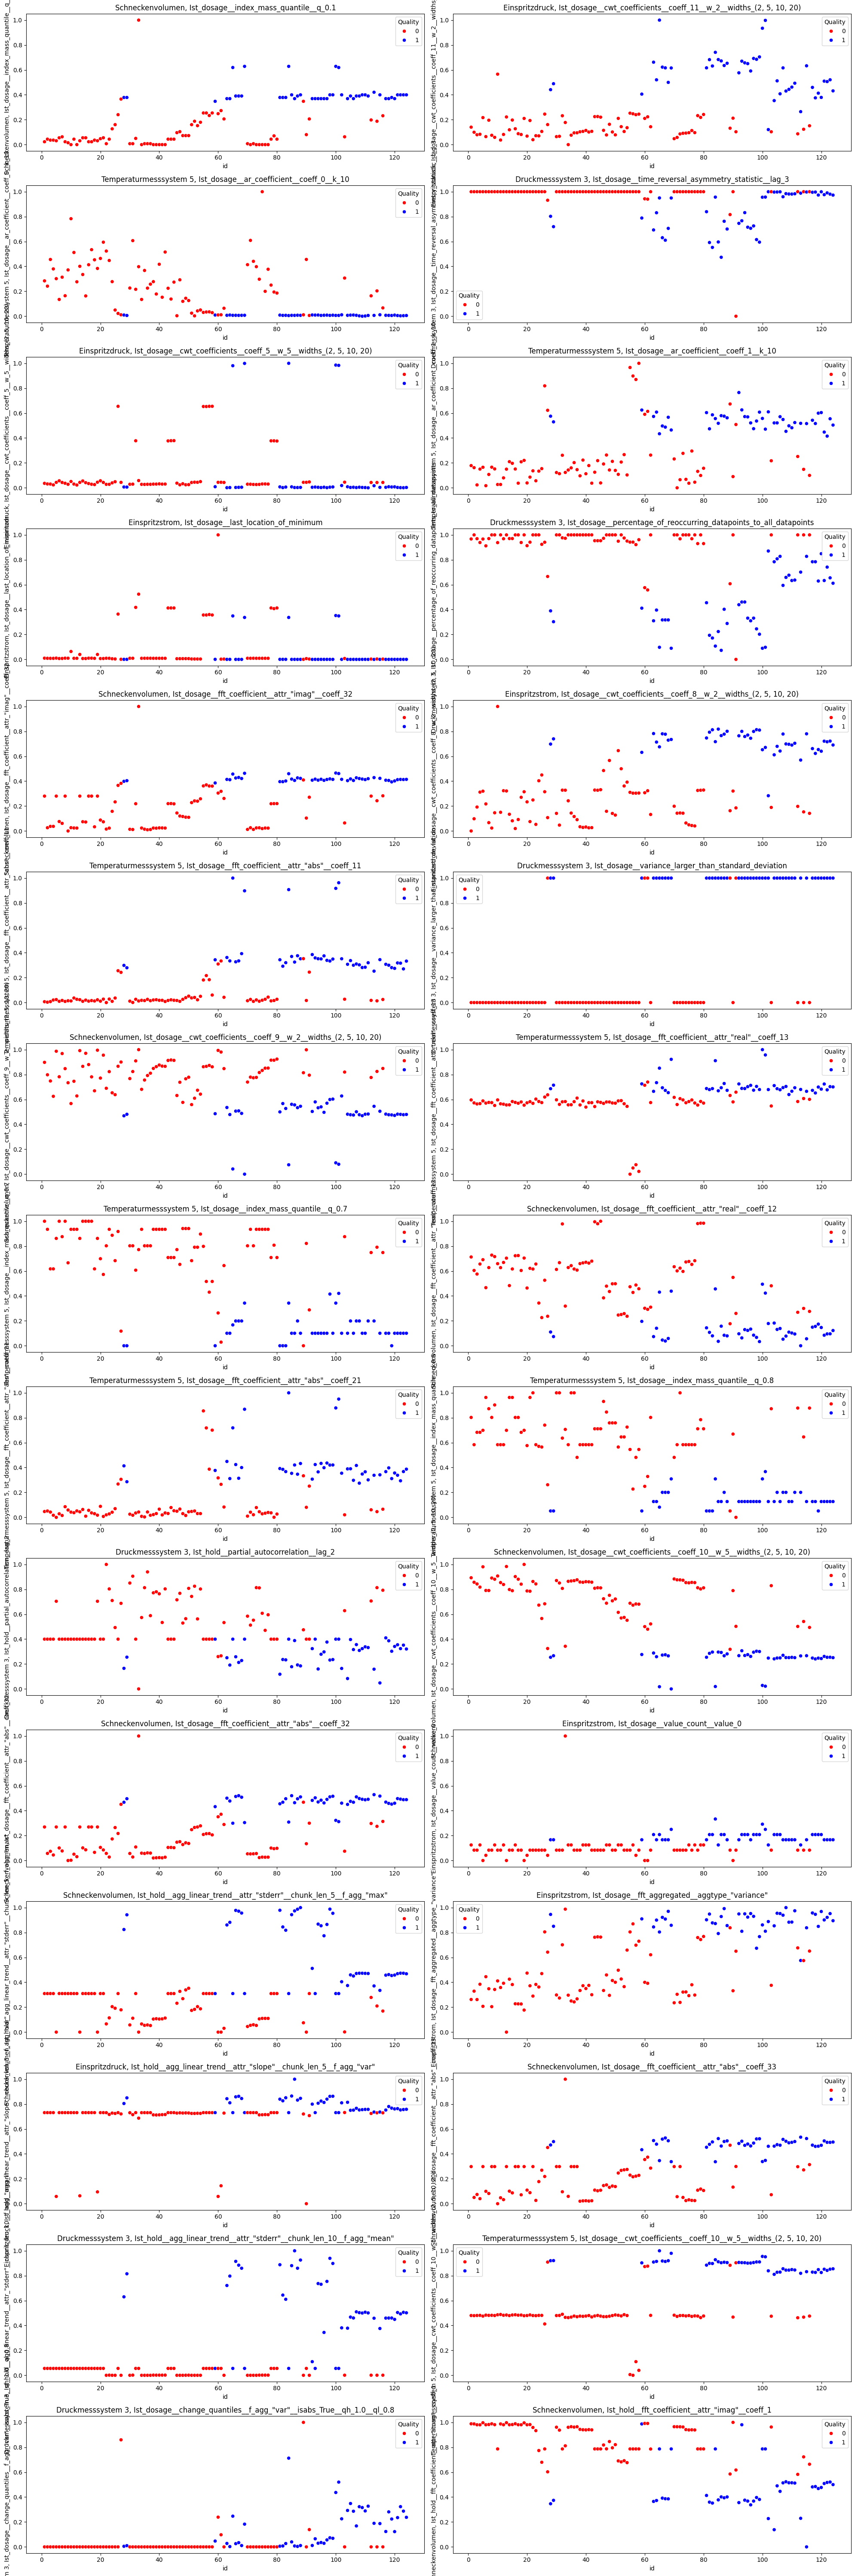

In [326]:
plot_selected_features(X_train_final, y_train, 30)

In [140]:
X_train_final.columns


Index(['Schneckenvolumen, Ist_dosage__cwt_coefficients__coeff_10__w_2__widths_(2, 5, 10, 20)',
       'Auswerferweg, Ist_dosage__fourier_entropy__bins_3',
       'Schneckenvolumen, Ist_dosage__index_mass_quantile__q_0.1',
       'Druckmesssystem 3, Ist_dosage__fft_coefficient__attr_"imag"__coeff_2',
       'Temperaturmesssystem 5, Ist_dosage__fft_coefficient__attr_"imag"__coeff_2',
       'Auswerferweg, Ist_dosage__agg_autocorrelation__f_agg_"mean"__maxlag_40',
       'Druckmesssystem 3, Ist_dosage__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4',
       'Schneckenvolumen, Ist_dosage__fft_coefficient__attr_"imag"__coeff_32',
       'Einspritzdruck, Ist_dosage__cwt_coefficients__coeff_11__w_2__widths_(2, 5, 10, 20)',
       'Temperaturmesssystem 5, Ist_dosage__ar_coefficient__coeff_0__k_10',
       'Einspritzdruck, Ist_dosage__cwt_coefficients__coeff_14__w_2__widths_(2, 5, 10, 20)',
       'Temperaturmesssystem 5, Ist_dosage__index_mass_quantile__q_0.6',
       'Schneckenvol